In [37]:

import os
import random
import requests
import warnings
from datetime import datetime
from datetime import datetime, timedelta

import holidays
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import itertools
from datetime import timedelta


# Suppress warnings
warnings.filterwarnings('ignore')

# Statistical and ML libraries
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif

# Time series specific libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy import stats 
# Scikit-learn utilities
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep learning libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

In [38]:
final_df = pd.read_csv(r'C:\Users\TPWODL\New folder_Content\DeepLearning_TimeSeries_LSTM_End_To_End\data\raw\PowerLoad_Dataset.csv')

In [39]:
final_df

,Timestamp,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,DayOfWeek,HolidayFlag,Daily_PostDispatch_Load,Weekly_PreDispatch_Projection
0,01-01-2018 01:00,493.09,20.47,66.90,10.35,0.51,1,0,508.96,519.14
1,01-01-2018 04:00,488.29,27.66,58.72,7.86,0.02,1,0,522.95,533.41
2,01-01-2018 07:00,538.37,15.35,36.77,4.67,0.05,1,0,527.55,538.10
3,01-01-2018 13:00,404.34,22.89,83.71,11.05,0.22,1,0,506.71,516.85
4,02-01-2018 14:00,433.59,20.38,43.12,0.51,0.18,2,0,481.05,498.31
...,...,...,...,...,...,...,...,...,...,...
9995,29-06-2023 16:00,549.45,41.41,51.86,1.89,0.00,4,0,509.40,511.15
9996,29-06-2023 17:00,513.91,26.63,34.00,7.73,0.42,4,0,508.86,511.26
9997,30-06-2023 03:00,582.84,21.08,32.43,12.56,0.05,5,0,525.95,515.83
9998,30-06-2023 12:00,480.59,19.23,46.33,14.09,0.00,5,0,525.80,515.69


In [40]:
final_df.columns

Index(['Timestamp', 'Power_Load_kW', 'Temperature_C', 'Humidity_%',
       'WindSpeed_mps', 'Precipitation_mm', 'DayOfWeek', 'HolidayFlag',
       'Daily_PostDispatch_Load', 'Weekly_PreDispatch_Projection'],
      dtype='object')

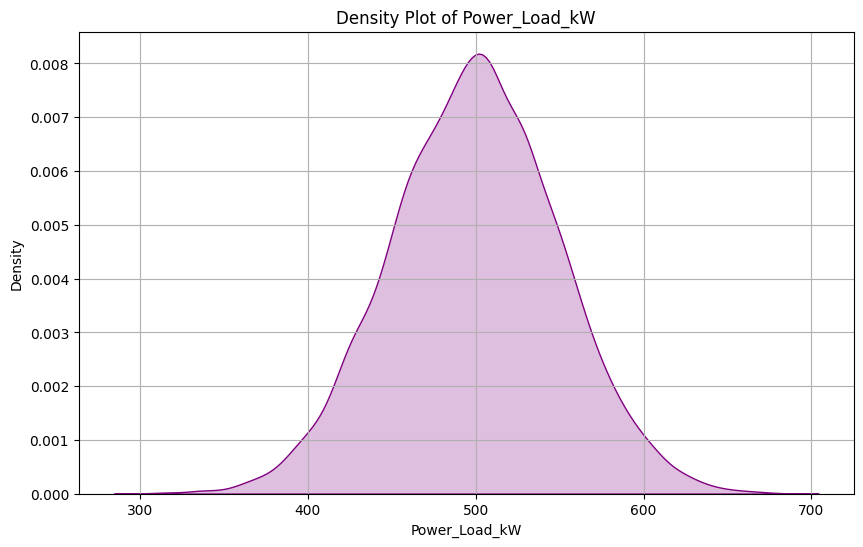

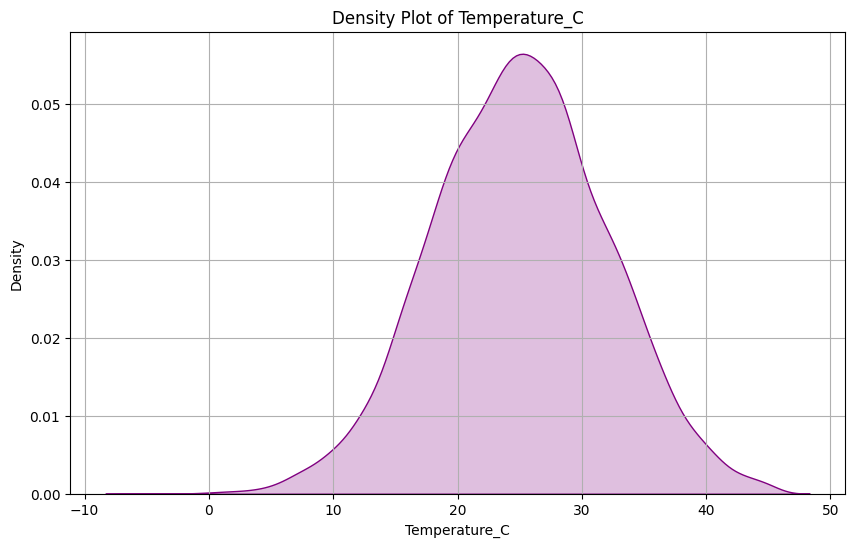

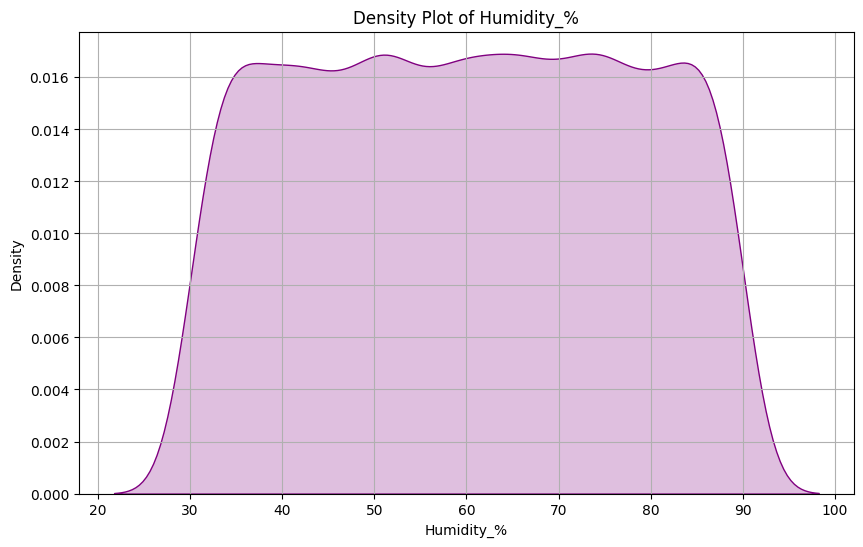

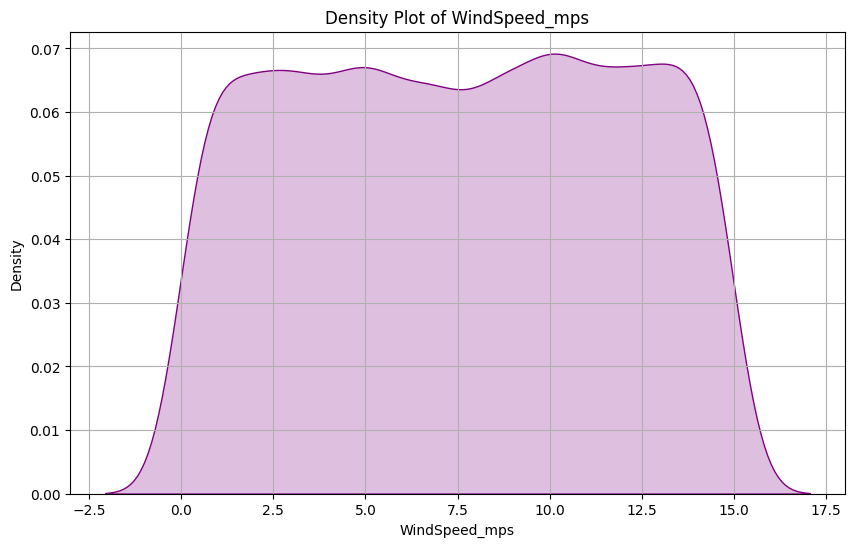

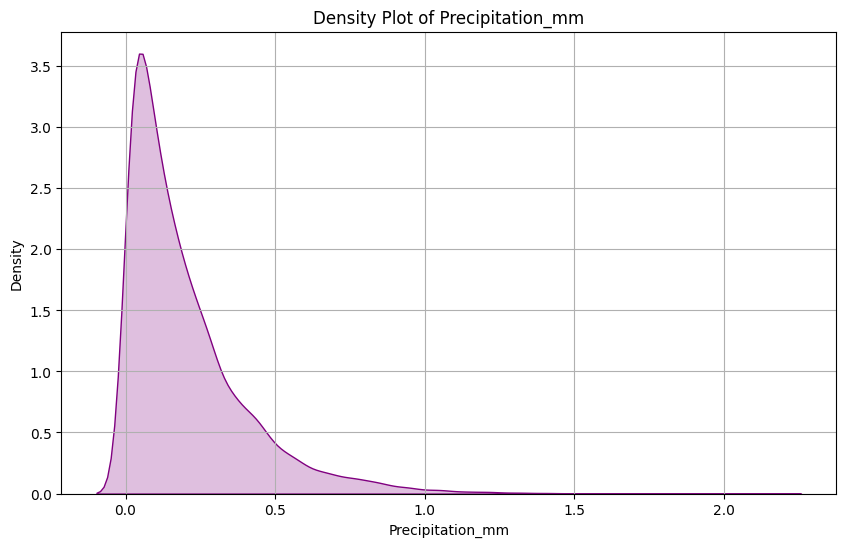

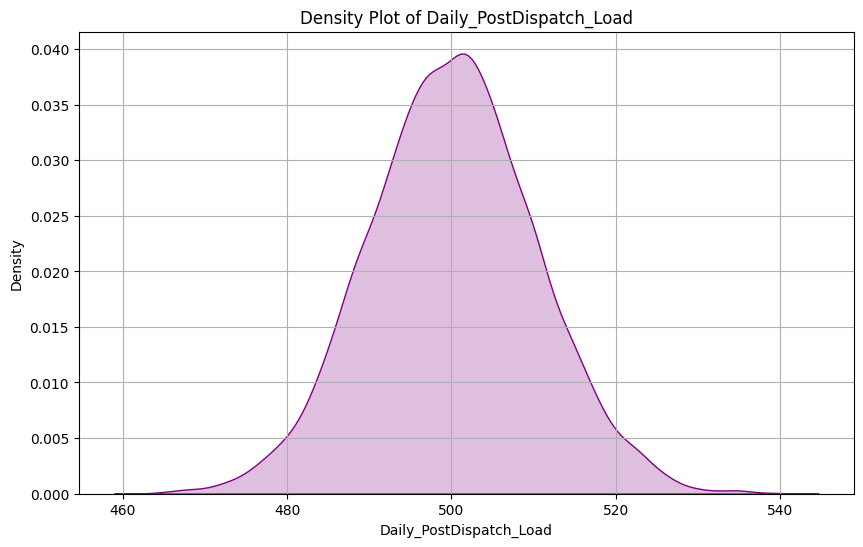

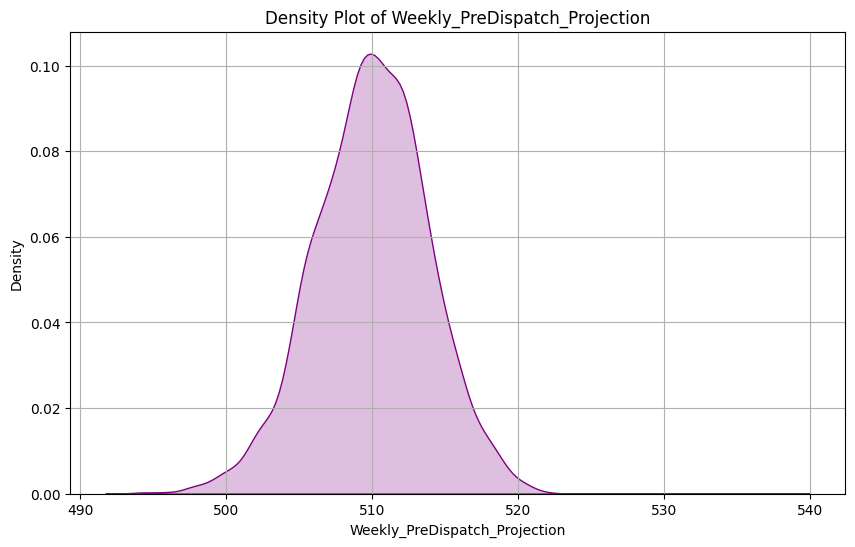

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to plot
columns_to_plot = ['Power_Load_kW', 'Temperature_C', 'Humidity_%',
       'WindSpeed_mps', 'Precipitation_mm','Daily_PostDispatch_Load', 'Weekly_PreDispatch_Projection']

# Loop through each column and plot KDE
for col in columns_to_plot:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(final_df[col], shade=True, color='purple')
    plt.title(f'Density Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()

#### Core Data checking Cleaning

In [42]:
final_df.head(2)

,Timestamp,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,DayOfWeek,HolidayFlag,Daily_PostDispatch_Load,Weekly_PreDispatch_Projection
0,01-01-2018 01:00,493.09,20.47,66.90,10.35,0.51,1,0,508.96,519.14
1,01-01-2018 04:00,488.29,27.66,58.72,7.86,0.02,1,0,522.95,533.41


In [43]:
final_df.dtypes

Timestamp                         object
Power_Load_kW                    float64
Temperature_C                    float64
Humidity_%                       float64
WindSpeed_mps                    float64
Precipitation_mm                 float64
DayOfWeek                          int64
HolidayFlag                        int64
Daily_PostDispatch_Load          float64
Weekly_PreDispatch_Projection    float64
dtype: object

In [44]:
final_df.shape

(10000, 10)

In [45]:
final_df.isnull().sum()

Timestamp                        0
Power_Load_kW                    0
Temperature_C                    0
Humidity_%                       0
WindSpeed_mps                    0
Precipitation_mm                 0
DayOfWeek                        0
HolidayFlag                      0
Daily_PostDispatch_Load          0
Weekly_PreDispatch_Projection    0
dtype: int64

In [46]:
final_df.duplicated().sum()

np.int64(0)

In [47]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Timestamp                      10000 non-null  object 
 1   Power_Load_kW                  10000 non-null  float64
 2   Temperature_C                  10000 non-null  float64
 3   Humidity_%                     10000 non-null  float64
 4   WindSpeed_mps                  10000 non-null  float64
 5   Precipitation_mm               10000 non-null  float64
 6   DayOfWeek                      10000 non-null  int64  
 7   HolidayFlag                    10000 non-null  int64  
 8   Daily_PostDispatch_Load        10000 non-null  float64
 9   Weekly_PreDispatch_Projection  10000 non-null  float64
dtypes: float64(7), int64(2), object(1)
memory usage: 781.4+ KB


In [48]:
final_df.describe()

,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,DayOfWeek,HolidayFlag,Daily_PostDispatch_Load,Weekly_PreDispatch_Projection
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,499.397814,25.022674,60.126286,7.516845,0.202565,3.982500,0.285400,500.112020,509.946114
std,49.880756,7.026358,17.334169,4.346676,0.204053,2.010771,0.451627,10.137719,3.916816
min,308.170000,-5.000000,30.000000,0.000000,0.000000,1.000000,0.000000,463.760000,493.590000
25%,465.467500,20.200000,45.077500,3.757500,0.060000,2.000000,0.000000,493.330000,507.370000
50%,499.985000,25.050000,60.230000,7.560000,0.140000,4.000000,0.000000,500.110000,510.030000
75%,532.900000,29.690000,74.960000,11.270000,0.280000,6.000000,1.000000,506.770000,512.570000
max,680.570000,45.000000,89.990000,15.000000,2.160000,7.000000,1.000000,539.850000,538.100000


In [49]:


# Core Data Check / Validation
print("🔍 Core Data Validation")
print("Shape:", final_df.shape)
print("Data Types:\n", final_df.dtypes)
print("Missing Values:\n", final_df.isnull().sum())
print("Duplicate Rows:", final_df.duplicated().sum())

    

🔍 Core Data Validation
Shape: (10000, 10)
Data Types:
 Timestamp                         object
Power_Load_kW                    float64
Temperature_C                    float64
Humidity_%                       float64
WindSpeed_mps                    float64
Precipitation_mm                 float64
DayOfWeek                          int64
HolidayFlag                        int64
Daily_PostDispatch_Load          float64
Weekly_PreDispatch_Projection    float64
dtype: object
Missing Values:
 Timestamp                        0
Power_Load_kW                    0
Temperature_C                    0
Humidity_%                       0
WindSpeed_mps                    0
Precipitation_mm                 0
DayOfWeek                        0
HolidayFlag                      0
Daily_PostDispatch_Load          0
Weekly_PreDispatch_Projection    0
dtype: int64
Duplicate Rows: 0


In [50]:
final_df.columns

Index(['Timestamp', 'Power_Load_kW', 'Temperature_C', 'Humidity_%',
       'WindSpeed_mps', 'Precipitation_mm', 'DayOfWeek', 'HolidayFlag',
       'Daily_PostDispatch_Load', 'Weekly_PreDispatch_Projection'],
      dtype='object')

In [ ]:
df = final_df[['Timestamp', 'Power_Load_kW', 'Temperature_C', 'Humidity_%',
       'WindSpeed_mps', 'Precipitation_mm']]

In [ ]:
df.head(10)  

,Timestamp,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm
0,01-01-2018 01:00,493.09,20.47,66.90,10.35,0.51
1,01-01-2018 04:00,488.29,27.66,58.72,7.86,0.02
2,01-01-2018 07:00,538.37,15.35,36.77,4.67,0.05
3,01-01-2018 13:00,404.34,22.89,83.71,11.05,0.22
4,02-01-2018 14:00,433.59,20.38,43.12,0.51,0.18
5,02-01-2018 16:00,536.92,23.20,30.63,8.09,0.05
6,03-01-2018 01:00,411.85,14.81,39.98,0.28,0.10
7,03-01-2018 13:00,490.72,19.23,69.90,1.16,0.05
8,03-01-2018 14:00,444.68,23.90,41.42,5.62,0.32
9,03-01-2018 22:00,518.07,21.15,54.70,5.03,0.25


#### Data Preprocessing and Feature Engineering

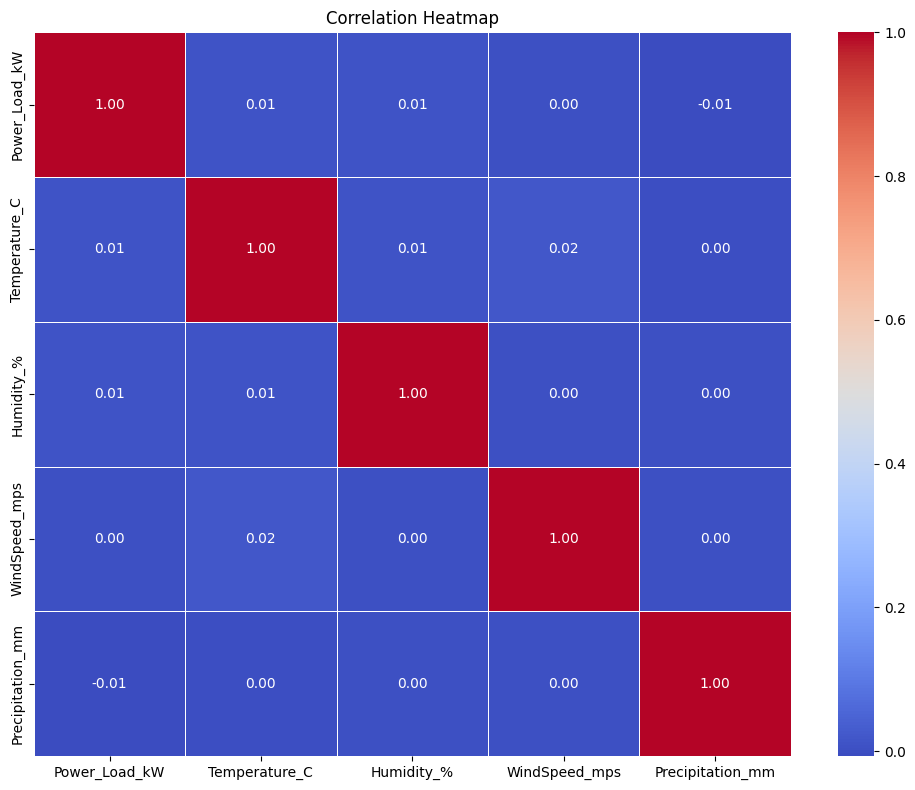

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
# df = pd.read_csv("your_data.csv")  # Replace with your actual file

# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [ ]:
# Ensure datetime is parsed
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format="%d-%m-%Y %H:%M")

In [55]:
df

,Timestamp,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm
0,2018-01-01 01:00:00,493.09,20.47,66.90,10.35,0.51
1,2018-01-01 04:00:00,488.29,27.66,58.72,7.86,0.02
2,2018-01-01 07:00:00,538.37,15.35,36.77,4.67,0.05
3,2018-01-01 13:00:00,404.34,22.89,83.71,11.05,0.22
4,2018-01-02 14:00:00,433.59,20.38,43.12,0.51,0.18
...,...,...,...,...,...,...
9995,2023-06-29 16:00:00,549.45,41.41,51.86,1.89,0.00
9996,2023-06-29 17:00:00,513.91,26.63,34.00,7.73,0.42
9997,2023-06-30 03:00:00,582.84,21.08,32.43,12.56,0.05
9998,2023-06-30 12:00:00,480.59,19.23,46.33,14.09,0.00


In [56]:
# ===== CORE TIME FEATURES =====
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['day_of_month'] = df['Timestamp'].dt.day
df['day_of_year'] = df['Timestamp'].dt.dayofyear

In [57]:
df

,Timestamp,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,hour,day_of_week,day_of_month,day_of_year
0,2018-01-01 01:00:00,493.09,20.47,66.90,10.35,0.51,1,0,1,1
1,2018-01-01 04:00:00,488.29,27.66,58.72,7.86,0.02,4,0,1,1
2,2018-01-01 07:00:00,538.37,15.35,36.77,4.67,0.05,7,0,1,1
3,2018-01-01 13:00:00,404.34,22.89,83.71,11.05,0.22,13,0,1,1
4,2018-01-02 14:00:00,433.59,20.38,43.12,0.51,0.18,14,1,2,2
...,...,...,...,...,...,...,...,...,...,...
9995,2023-06-29 16:00:00,549.45,41.41,51.86,1.89,0.00,16,3,29,180
9996,2023-06-29 17:00:00,513.91,26.63,34.00,7.73,0.42,17,3,29,180
9997,2023-06-30 03:00:00,582.84,21.08,32.43,12.56,0.05,3,4,30,181
9998,2023-06-30 12:00:00,480.59,19.23,46.33,14.09,0.00,12,4,30,181


#### Correlation Analysis:

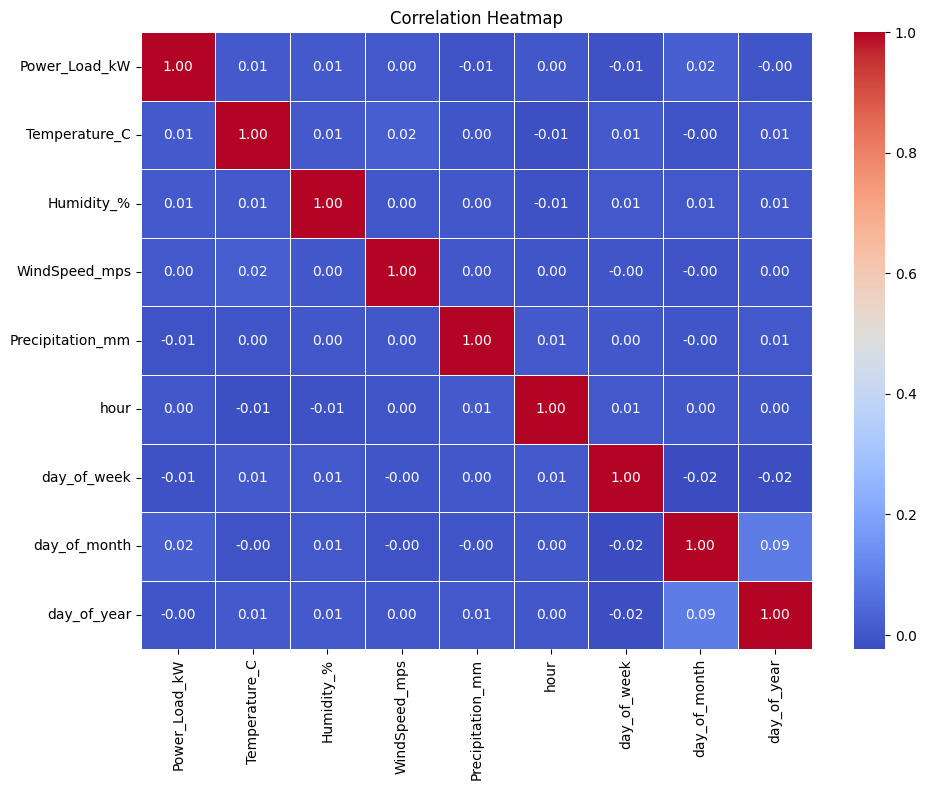

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
# df = pd.read_csv("your_data.csv")  # Replace with your actual file

# Compute correlation matrix
corr_matrix02 = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix02, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [60]:
# ===== CYCLIC (PERIODIC) FEATURES =====
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dayofweek_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['dayofmonth_sin'] = np.sin(2 * np.pi * df['day_of_month'] / 31)
df['dayofmonth_cos'] = np.cos(2 * np.pi * df['day_of_month'] / 31)
df['dayofyear_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

In [61]:
df

,Timestamp,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,hour,day_of_week,day_of_month,day_of_year,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
0,2018-01-01 01:00:00,493.09,20.47,66.90,10.35,0.51,1,0,1,1,2.588190e-01,0.965926,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
1,2018-01-01 04:00:00,488.29,27.66,58.72,7.86,0.02,4,0,1,1,8.660254e-01,0.500000,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
2,2018-01-01 07:00:00,538.37,15.35,36.77,4.67,0.05,7,0,1,1,9.659258e-01,-0.258819,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
3,2018-01-01 13:00:00,404.34,22.89,83.71,11.05,0.22,13,0,1,1,-2.588190e-01,-0.965926,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
4,2018-01-02 14:00:00,433.59,20.38,43.12,0.51,0.18,14,1,2,2,-5.000000e-01,-0.866025,0.781831,0.623490,0.394356,0.918958,0.034422,0.999407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2023-06-29 16:00:00,549.45,41.41,51.86,1.89,0.00,16,3,29,180,-8.660254e-01,-0.500000,0.433884,-0.900969,-0.394356,0.918958,0.043022,-0.999074
9996,2023-06-29 17:00:00,513.91,26.63,34.00,7.73,0.42,17,3,29,180,-9.659258e-01,-0.258819,0.433884,-0.900969,-0.394356,0.918958,0.043022,-0.999074
9997,2023-06-30 03:00:00,582.84,21.08,32.43,12.56,0.05,3,4,30,181,7.071068e-01,0.707107,-0.433884,-0.900969,-0.201299,0.979530,0.025818,-0.999667
9998,2023-06-30 12:00:00,480.59,19.23,46.33,14.09,0.00,12,4,30,181,1.224647e-16,-1.000000,-0.433884,-0.900969,-0.201299,0.979530,0.025818,-0.999667


In [62]:
df.columns

Index(['Timestamp', 'Power_Load_kW', 'Temperature_C', 'Humidity_%',
       'WindSpeed_mps', 'Precipitation_mm', 'hour', 'day_of_week',
       'day_of_month', 'day_of_year', 'hour_sin', 'hour_cos', 'dayofweek_sin',
       'dayofweek_cos', 'dayofmonth_sin', 'dayofmonth_cos', 'dayofyear_sin',
       'dayofyear_cos'],
      dtype='object')

In [63]:
new_df = df[['Timestamp', 'Power_Load_kW', 'Temperature_C', 'Humidity_%',
       'WindSpeed_mps', 'Precipitation_mm', 'hour_sin', 'hour_cos', 'dayofweek_sin',
       'dayofweek_cos', 'dayofmonth_sin', 'dayofmonth_cos', 'dayofyear_sin',
       'dayofyear_cos']]

In [64]:
new_df

,Timestamp,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
0,2018-01-01 01:00:00,493.09,20.47,66.90,10.35,0.51,2.588190e-01,0.965926,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
1,2018-01-01 04:00:00,488.29,27.66,58.72,7.86,0.02,8.660254e-01,0.500000,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
2,2018-01-01 07:00:00,538.37,15.35,36.77,4.67,0.05,9.659258e-01,-0.258819,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
3,2018-01-01 13:00:00,404.34,22.89,83.71,11.05,0.22,-2.588190e-01,-0.965926,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
4,2018-01-02 14:00:00,433.59,20.38,43.12,0.51,0.18,-5.000000e-01,-0.866025,0.781831,0.623490,0.394356,0.918958,0.034422,0.999407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2023-06-29 16:00:00,549.45,41.41,51.86,1.89,0.00,-8.660254e-01,-0.500000,0.433884,-0.900969,-0.394356,0.918958,0.043022,-0.999074
9996,2023-06-29 17:00:00,513.91,26.63,34.00,7.73,0.42,-9.659258e-01,-0.258819,0.433884,-0.900969,-0.394356,0.918958,0.043022,-0.999074
9997,2023-06-30 03:00:00,582.84,21.08,32.43,12.56,0.05,7.071068e-01,0.707107,-0.433884,-0.900969,-0.201299,0.979530,0.025818,-0.999667
9998,2023-06-30 12:00:00,480.59,19.23,46.33,14.09,0.00,1.224647e-16,-1.000000,-0.433884,-0.900969,-0.201299,0.979530,0.025818,-0.999667


#### | Box Plot — boxplot

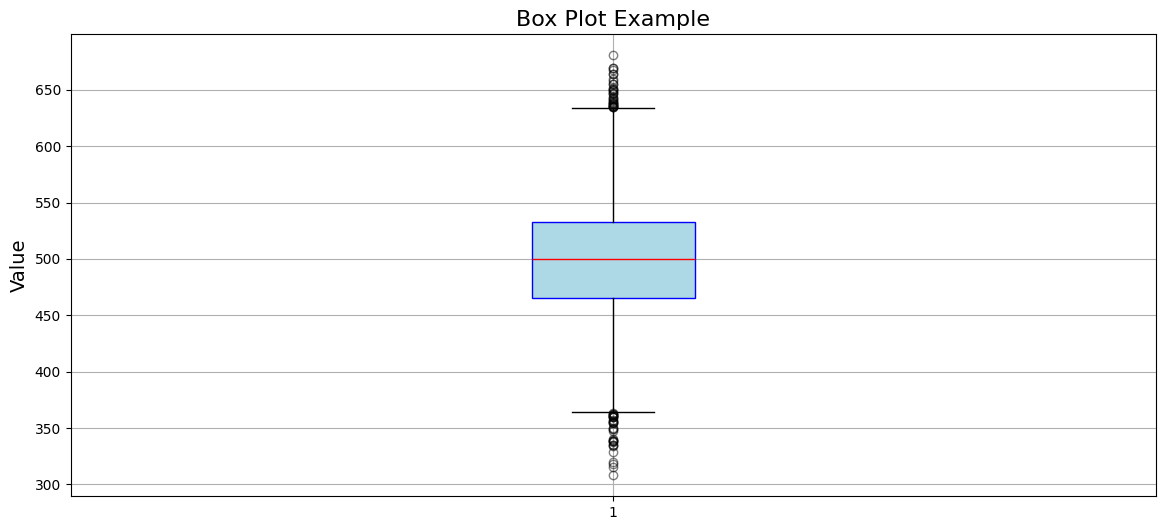

In [81]:
import matplotlib.pyplot as plt

# Create box plot
plt.figure(figsize=(14, 6))  # Optional: enlarge canvas
plt.boxplot(new_df['Power_Load_kW'], patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red'), whiskerprops=dict(color='black'),
            capprops=dict(color='black'), flierprops=dict(marker='o', color='orange', alpha=0.5))

# Add title and labels
plt.title('Box Plot Example', fontsize=16)
plt.ylabel('Value', fontsize=14)

# Show plot
plt.grid(True)
plt.show()

#### | Box Plot — boxplot outlier

Total data points: 10000
Outliers detected: 69
Outlier values: [337.94, 655.5, 640.73, 357.27, 355.02, 639.0, 635.54, 347.77, 647.15, 639.61, 315.58, 636.1, 319.95, 308.17, 668.87, 657.89, 359.9, 338.37, 361.63, 333.94, 648.48, 664.21, 664.29, 334.61, 654.83, 349.47, 649.86, 362.93, 635.33, 646.52, 356.2, 359.56, 680.57, 335.22, 651.91, 643.36, 348.97, 362.93, 650.69, 643.1, 328.62, 634.74, 637.55, 667.41, 360.26, 360.69, 354.13, 361.28, 338.94, 637.88, 354.95, 641.63, 634.66, 649.73, 637.16, 339.44, 350.13, 355.24, 659.65, 318.42, 669.03, 360.98, 634.39, 647.56, 338.15, 363.13, 339.97, 636.02, 638.05]
Outlier values Len: 69


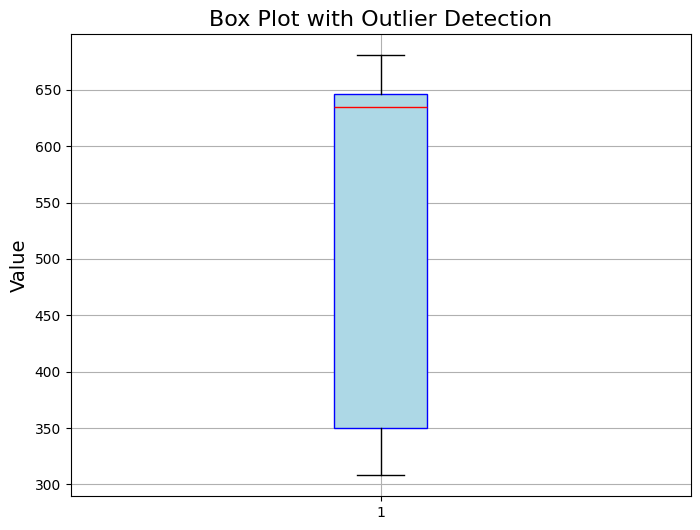

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to NumPy array for calculations
data_array = np.array(new_df['Power_Load_kW'])

# Calculate Q1, Q3, and IQR
Q1 = np.percentile(data_array, 25)
Q3 = np.percentile(data_array, 75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = data_array[(data_array < lower_bound) | (data_array > upper_bound)]

# Print outlier info
print(f"Total data points: {len(data_array)}")
print(f"Outliers detected: {len(outliers)}")
print(f"Outlier values: {outliers.tolist()}")
print(f"Outlier values Len: {len(outliers)}")

# Create box plot
plt.figure(figsize=(8, 6))
plt.boxplot(outliers, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', color='orange', alpha=0.5))

# Add title and labels
plt.title('Box Plot with Outlier Detection', fontsize=16)
plt.ylabel('Value', fontsize=14)
plt.grid(True)
plt.show()


#### Scatter Plot — scatter

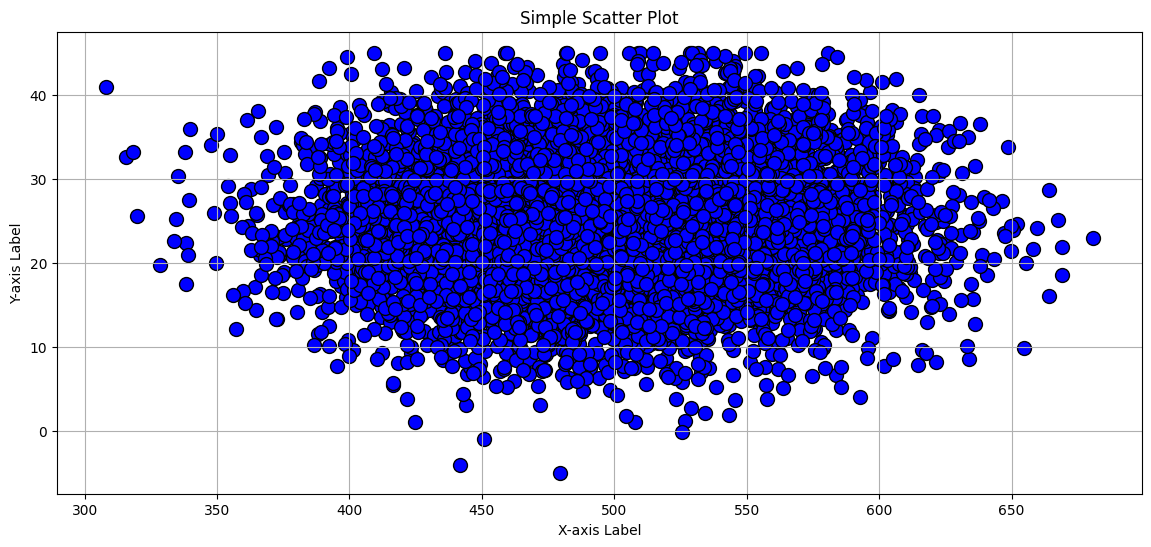

In [ ]:
# Create scatter plot
plt.figure(figsize=(14, 6))  # Optional: enlarge canvas
plt.scatter(new_df['Power_Load_kW'], new_df['Temperature_C'], color='blue', marker='o', s=100, edgecolors='black')

# Add labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Simple Scatter Plot')

# Show plot
plt.grid(True)
plt.show()

#### Correlation Analysis:

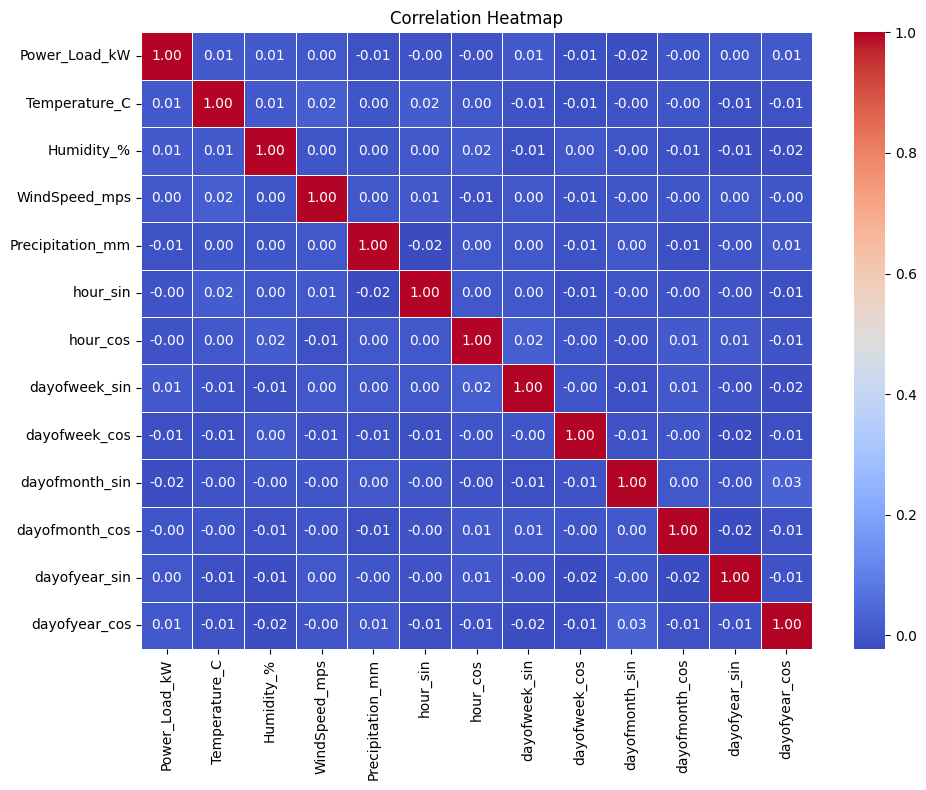

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
# df = pd.read_csv("your_data.csv")  # Replace with your actual file

# Compute correlation matrix
corr_matrix03 = new_df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix03, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#### VARIANCE THRESHOLD FEATURE SELECTION

Feature Variances:
 Power_Load_kW       2488.089865
Temperature_C         49.369700
Humidity_%           300.473412
WindSpeed_mps         18.893588
Precipitation_mm       0.041638
hour_sin               0.499078
hour_cos               0.500790
dayofweek_sin          0.499315
dayofweek_cos          0.500654
dayofmonth_sin         0.510138
dayofmonth_cos         0.489651
dayofyear_sin          0.496181
dayofyear_cos          0.500241
dtype: float64

Selected Features (Variance > threshold):
['Power_Load_kW', 'Temperature_C', 'Humidity_%', 'WindSpeed_mps', 'Precipitation_mm', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'dayofmonth_sin', 'dayofmonth_cos', 'dayofyear_sin', 'dayofyear_cos']

Original shape: (10000, 13)
Reduced shape: (10000, 13)


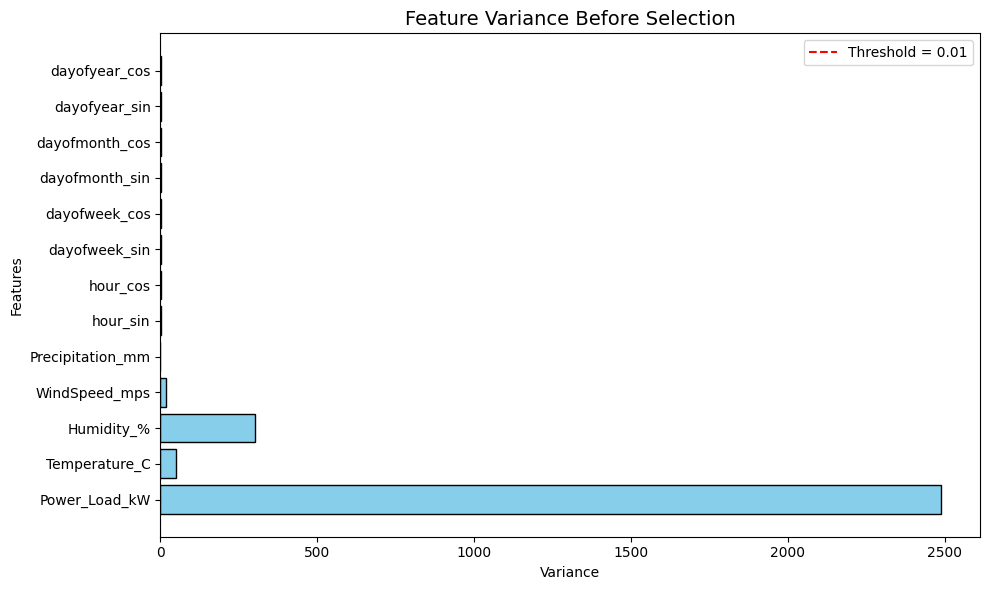

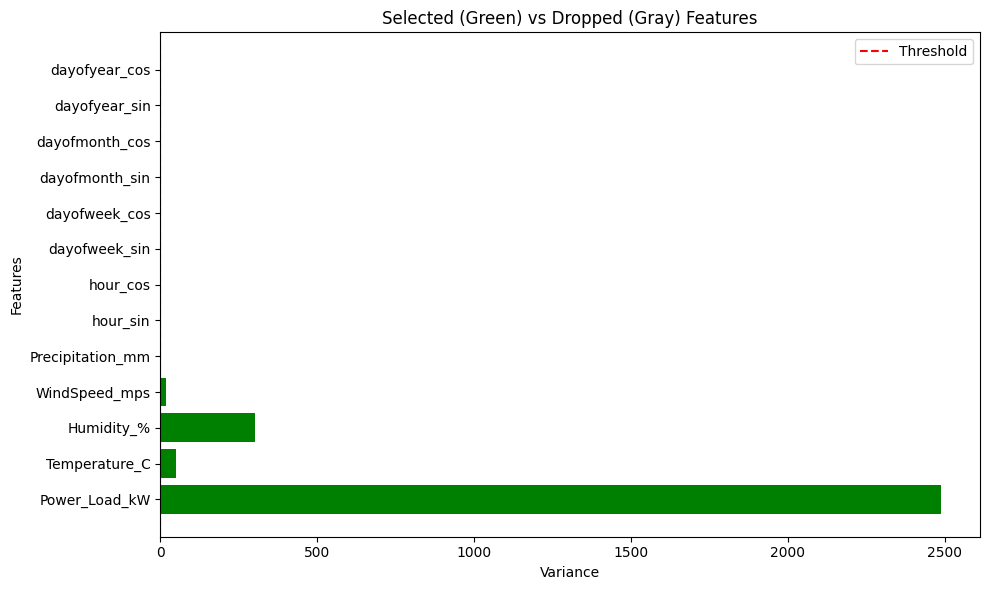

In [66]:
# ============================================
# VARIANCE THRESHOLD FEATURE SELECTION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# ----- STEP 1: Load or prepare clean dataset -----
# Assume df is your clean DataFrame
# Example: df = pd.read_csv('data.csv')

# Remove non-numeric columns if present
df_numeric = new_df.select_dtypes(include=[np.number])

# ----- STEP 2: Check variance of all features -----
feature_variances = df_numeric.var()
print("Feature Variances:\n", feature_variances)

# ----- STEP 3: Apply VarianceThreshold -----
threshold = 0.01  # you can adjust this value (e.g., 0.0, 0.01, 0.02)
selector = VarianceThreshold(threshold=threshold)
X_selected = selector.fit_transform(df_numeric)

# Get selected feature names
selected_features = df_numeric.columns[selector.get_support()]
print("\nSelected Features (Variance > threshold):")
print(selected_features.tolist())

# ----- STEP 4: Create a new filtered DataFrame -----
df_selected = df_numeric[selected_features]
print(f"\nOriginal shape: {df_numeric.shape}")
print(f"Reduced shape: {df_selected.shape}")

# ----- STEP 5: Visualization - Variance Comparison -----
plt.figure(figsize=(10, 6))
plt.barh(df_numeric.columns, feature_variances, color='skyblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
plt.title('Feature Variance Before Selection', fontsize=14)
plt.xlabel('Variance')
plt.ylabel('Features')
plt.legend()
plt.tight_layout()
plt.show()

# ----- STEP 6: Visualization - Selected vs Dropped -----
plt.figure(figsize=(10, 6))
selected_mask = selector.get_support()
colors = ['green' if selected else 'gray' for selected in selected_mask]
plt.barh(df_numeric.columns, feature_variances, color=colors)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.title('Selected (Green) vs Dropped (Gray) Features')
plt.xlabel('Variance')
plt.ylabel('Features')
plt.legend()
plt.tight_layout()
plt.show()



#### MULTICOLLINEARITY CHECK USING VIF


Variance Inflation Factor (VIF) Results:

             Feature        VIF
0      Power_Load_kW  23.149102
1      Temperature_C  12.450447
2         Humidity_%  11.925689
3      WindSpeed_mps   3.911784
4   Precipitation_mm   1.970170
11     dayofyear_sin   1.008513
12     dayofyear_cos   1.002043
10    dayofmonth_cos   1.001584
6           hour_cos   1.001452
5           hour_sin   1.001250
7      dayofweek_sin   1.001208
8      dayofweek_cos   1.001140
9     dayofmonth_sin   1.000912

Features with high multicollinearity (VIF > 10):
         Feature        VIF
0  Power_Load_kW  23.149102
1  Temperature_C  12.450447
2     Humidity_%  11.925689


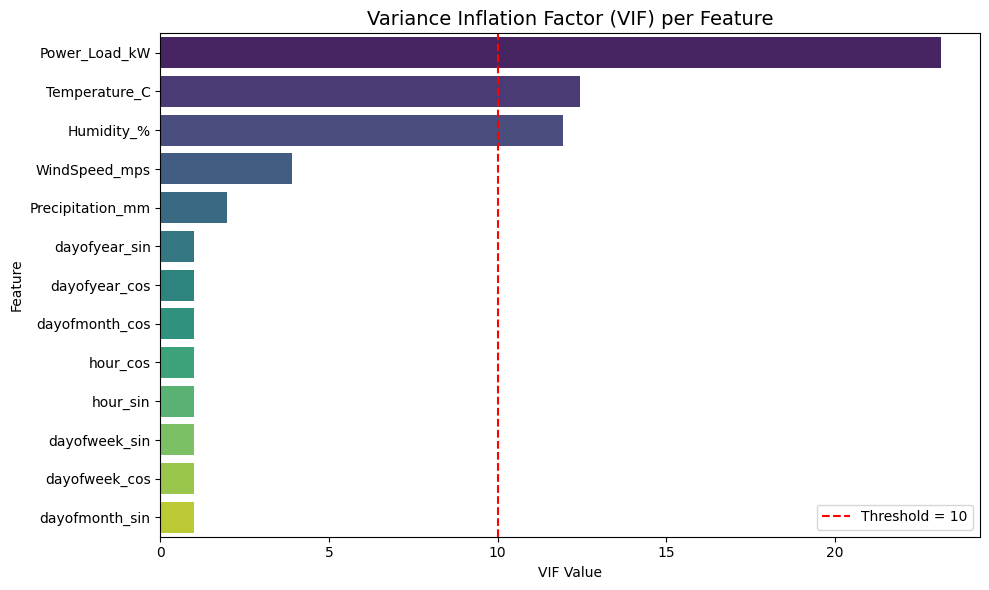

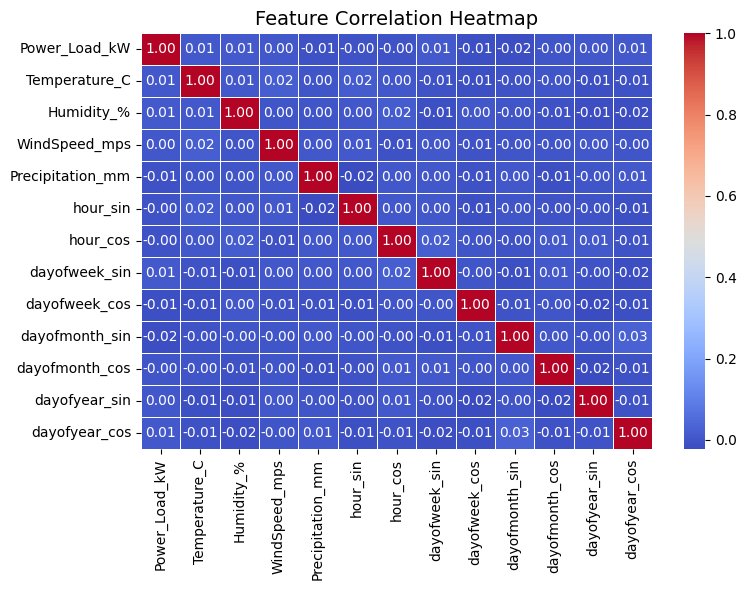

In [68]:
# ============================================
# MULTICOLLINEARITY CHECK USING VIF
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ----- STEP 1: Prepare the clean numeric data -----
# If you already have df_selected from VarianceThreshold, use it
# Otherwise:
# df_numeric = df.select_dtypes(include=[np.number])

df_numeric = new_df.select_dtypes(include=[np.number])

# ----- STEP 2: Compute VIF for each feature -----
vif_data = pd.DataFrame()
vif_data["Feature"] = df_numeric.columns
vif_data["VIF"] = [
    variance_inflation_factor(df_numeric.values, i) 
    for i in range(df_numeric.shape[1])
]

# ----- STEP 3: Sort by VIF for clarity -----
vif_data.sort_values(by="VIF", ascending=False, inplace=True)
print("\nVariance Inflation Factor (VIF) Results:\n")
print(vif_data)

# ----- STEP 4: Identify high VIF features -----
# Usually, VIF > 10 indicates multicollinearity
high_vif = vif_data[vif_data["VIF"] > 10]
print("\nFeatures with high multicollinearity (VIF > 10):")
print(high_vif)

# ----- STEP 5: Visualization - VIF Bar Chart -----
plt.figure(figsize=(10, 6))
sns.barplot(
    x="VIF", 
    y="Feature", 
    data=vif_data, 
    palette="viridis"
)
plt.axvline(10, color='red', linestyle='--', label='Threshold = 10')
plt.title("Variance Inflation Factor (VIF) per Feature", fontsize=14)
plt.xlabel("VIF Value")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()

# ----- STEP 6: Visualization - Correlation Heatmap -----
plt.figure(figsize=(8, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()


In [70]:
new_df.columns

Index(['Timestamp', 'Power_Load_kW', 'Temperature_C', 'Humidity_%',
       'WindSpeed_mps', 'Precipitation_mm', 'hour_sin', 'hour_cos',
       'dayofweek_sin', 'dayofweek_cos', 'dayofmonth_sin', 'dayofmonth_cos',
       'dayofyear_sin', 'dayofyear_cos'],
      dtype='object')

#### ANOVA F-Test Feature Selection with Visualization

=== ANOVA F-Test Feature Scores ===
             Feature   F_Score   P_Value
11     dayofyear_cos  1.041613  0.113981
5           hour_cos  1.030324  0.188710
0      Temperature_C  1.017879  0.300926
2      WindSpeed_mps  1.017437  0.305438
4           hour_sin  1.011335  0.370758
9     dayofmonth_cos  0.993267  0.582242
8     dayofmonth_sin  0.993231  0.582667
7      dayofweek_cos  0.991662  0.600994
3   Precipitation_mm  0.988397  0.638505
1         Humidity_%  0.988218  0.640538
6      dayofweek_sin  0.971345  0.809335
10     dayofyear_sin  0.943224  0.960672


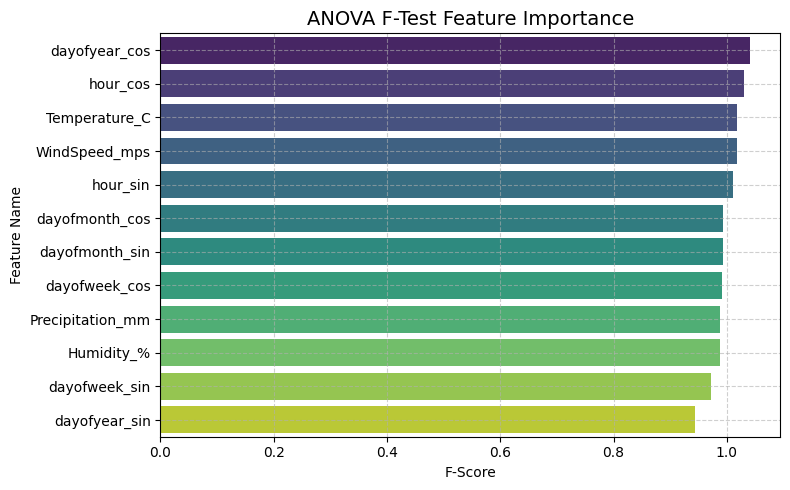


Significant Features (p < 0.05):
[]


In [74]:
# ==============================================
# ANOVA F-Test Feature Selection with Visualization
# ==============================================

import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# STEP 1: Load Data
# -------------------------------
# Example dataset
# Separate features and target
X01 = new_df.drop("Power_Load_kW", axis=1)  # Replace with your actual target column
y01 = new_df["Power_Load_kW"]

# Keep only numeric features
X_numeric = X01.select_dtypes(include='number')

# -------------------------------
# STEP 2: Apply ANOVA F-Test
# -------------------------------
# Select top k features (you can adjust k)
selector = SelectKBest(score_func=f_classif, k='all')  # use 'all' to get all scores
X_new = selector.fit_transform(X_numeric, y01)

# Get feature scores and p-values
anova_scores = selector.scores_
anova_pvalues = selector.pvalues_

# Combine results into a DataFrame
anova_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'F_Score': anova_scores,
    'P_Value': anova_pvalues
}).sort_values(by='F_Score', ascending=False)

print("=== ANOVA F-Test Feature Scores ===")
print(anova_df)

# -------------------------------
# STEP 3: Visualization
# -------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(x='F_Score', y='Feature', data=anova_df, palette='viridis')
plt.title("ANOVA F-Test Feature Importance", fontsize=14)
plt.xlabel("F-Score")
plt.ylabel("Feature Name")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# -------------------------------
# STEP 4: Filter Important Features (Optional)
# -------------------------------
# You can select features with p-value < 0.05 (statistically significant)
significant_features = anova_df[anova_df['P_Value'] < 0.05]['Feature']
print("\nSignificant Features (p < 0.05):")
print(significant_features.tolist())



In [88]:
new_df.head(1)

,Timestamp,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
0,2018-01-01 01:00:00,493.09,20.47,66.9,10.35,0.51,0.258819,0.965926,0.0,1.0,0.201299,0.97953,0.017213,0.999852


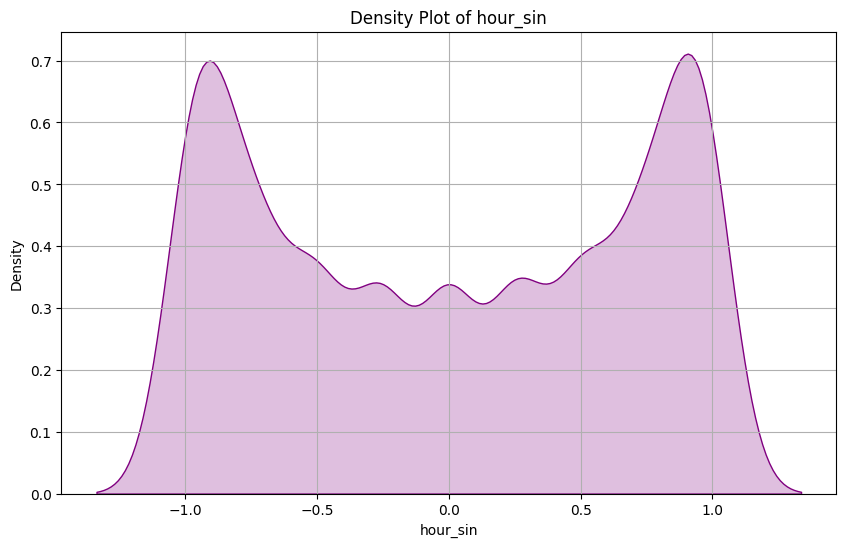

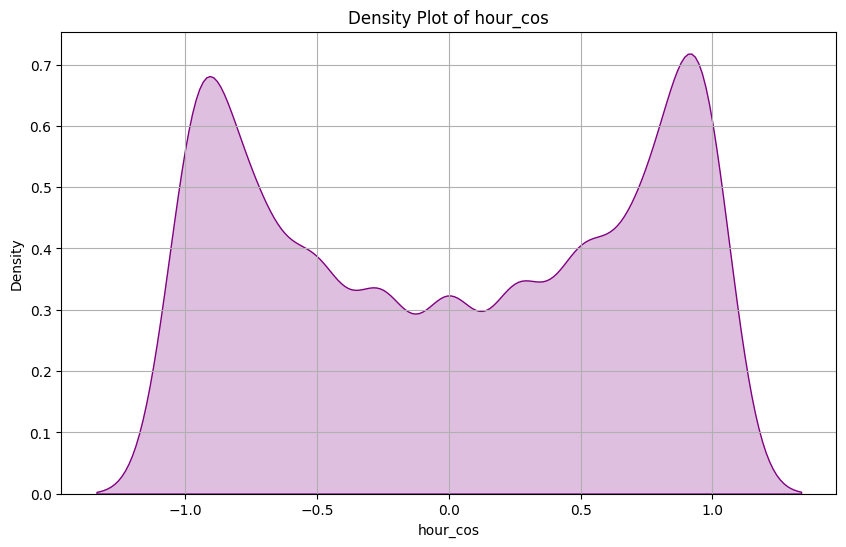

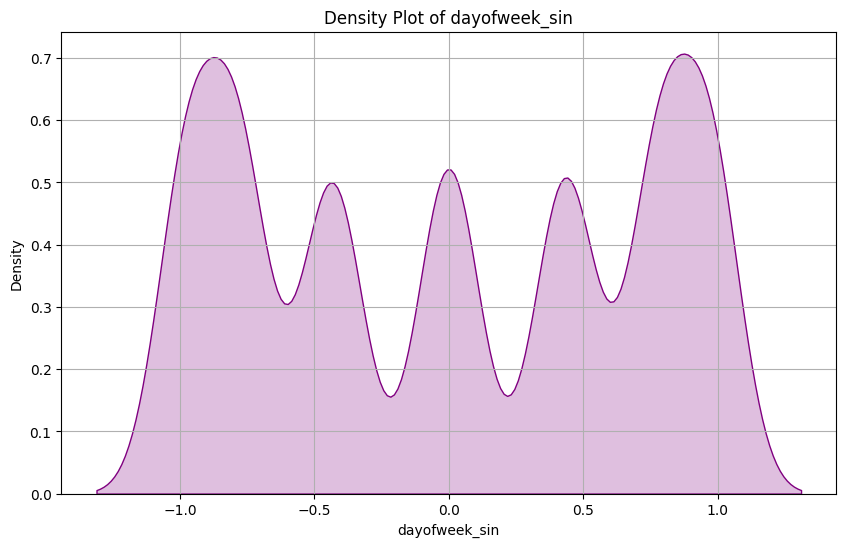

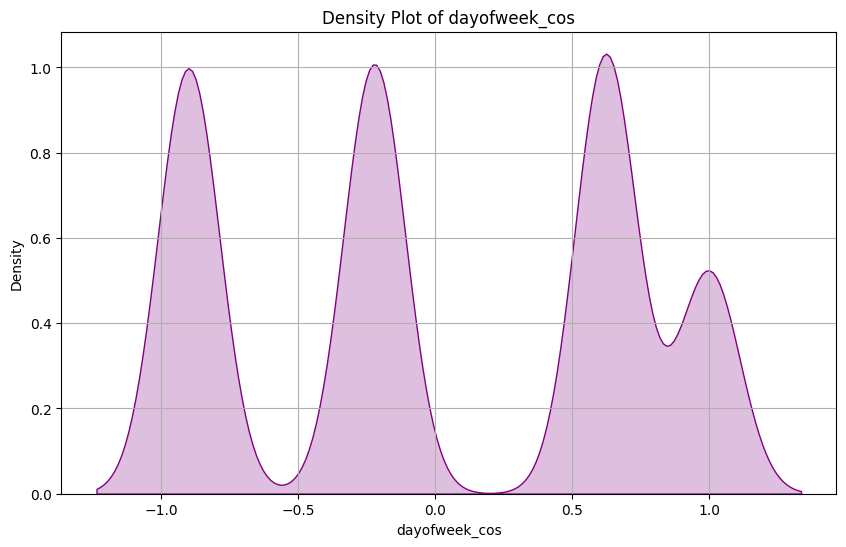

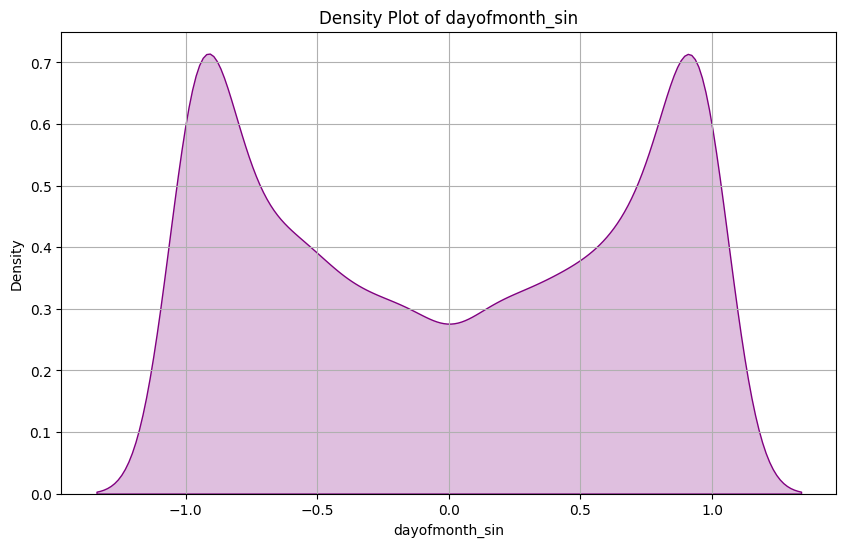

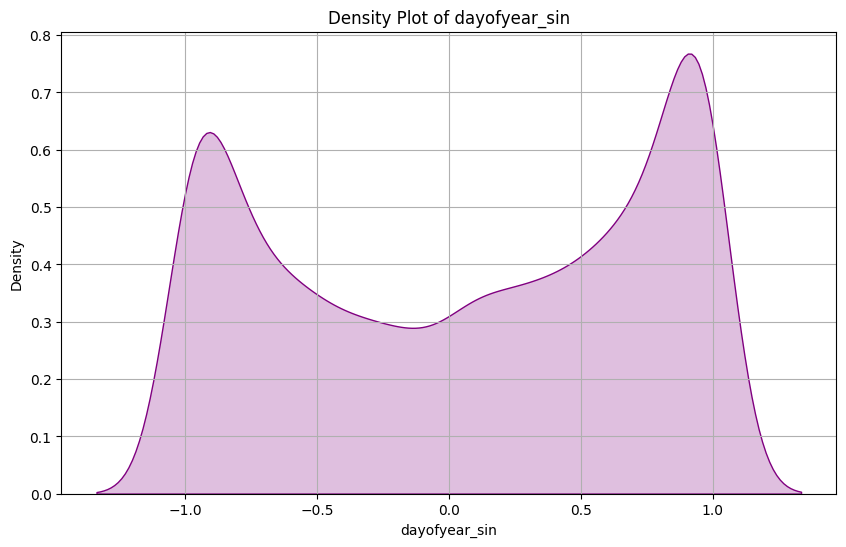

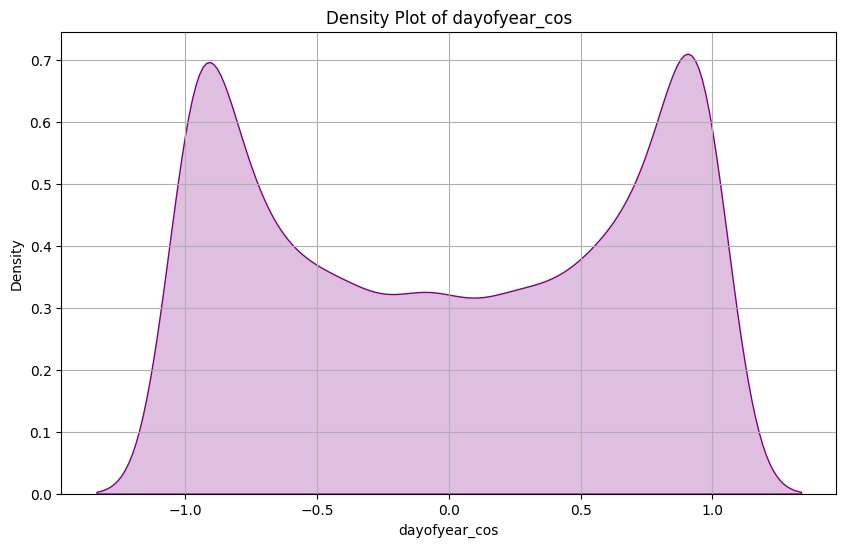

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to plot
columns_to_plot = ['hour_sin', 'hour_cos', 'dayofweek_sin',
       'dayofweek_cos', 'dayofmonth_sin','dayofyear_sin', 'dayofyear_cos']

# Loop through each column and plot KDE
for col in columns_to_plot:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(new_df[col], shade=True, color='purple')
    plt.title(f'Density Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()

In [91]:
new_df.columns

Index(['Timestamp', 'Power_Load_kW', 'Temperature_C', 'Humidity_%',
       'WindSpeed_mps', 'Precipitation_mm', 'hour_sin', 'hour_cos',
       'dayofweek_sin', 'dayofweek_cos', 'dayofmonth_sin', 'dayofmonth_cos',
       'dayofyear_sin', 'dayofyear_cos'],
      dtype='object')

 #### Feature Transformation

In [92]:
new_df.set_index("Timestamp", inplace=True)

In [93]:
new_df

,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
Timestamp,,,,,,,,,,,,,
2018-01-01 01:00:00,493.09,20.47,66.90,10.35,0.51,2.588190e-01,0.965926,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
2018-01-01 04:00:00,488.29,27.66,58.72,7.86,0.02,8.660254e-01,0.500000,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
2018-01-01 07:00:00,538.37,15.35,36.77,4.67,0.05,9.659258e-01,-0.258819,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
2018-01-01 13:00:00,404.34,22.89,83.71,11.05,0.22,-2.588190e-01,-0.965926,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
2018-01-02 14:00:00,433.59,20.38,43.12,0.51,0.18,-5.000000e-01,-0.866025,0.781831,0.623490,0.394356,0.918958,0.034422,0.999407
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-29 16:00:00,549.45,41.41,51.86,1.89,0.00,-8.660254e-01,-0.500000,0.433884,-0.900969,-0.394356,0.918958,0.043022,-0.999074
2023-06-29 17:00:00,513.91,26.63,34.00,7.73,0.42,-9.659258e-01,-0.258819,0.433884,-0.900969,-0.394356,0.918958,0.043022,-0.999074
2023-06-30 03:00:00,582.84,21.08,32.43,12.56,0.05,7.071068e-01,0.707107,-0.433884,-0.900969,-0.201299,0.979530,0.025818,-0.999667


#### train_test_split

In [96]:
# ============================================
# TRAIN–TEST SPLIT
# ============================================

# Define features (X) and target (y)
X = new_df.drop(columns=['Power_Load_kW'])   # replace 'target' with your target column name
y = new_df['Power_Load_kW']

# ----- STEP 2: Perform Train–Test Split -----
# Common split ratio: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,          # 20% test data
    random_state=42,        # ensures reproducibility
    )

# ----- STEP 3: Print summary -----
print(f"Training Set Shape : X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing Set Shape  : X_test  = {X_test.shape}, y_test  = {y_test.shape}")

Training Set Shape : X_train = (8000, 12), y_train = (8000,)
Testing Set Shape  : X_test  = (2000, 12), y_test  = (2000,)


In [97]:
X

,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
Timestamp,,,,,,,,,,,,
2018-01-01 01:00:00,20.47,66.90,10.35,0.51,2.588190e-01,0.965926,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
2018-01-01 04:00:00,27.66,58.72,7.86,0.02,8.660254e-01,0.500000,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
2018-01-01 07:00:00,15.35,36.77,4.67,0.05,9.659258e-01,-0.258819,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
2018-01-01 13:00:00,22.89,83.71,11.05,0.22,-2.588190e-01,-0.965926,0.000000,1.000000,0.201299,0.979530,0.017213,0.999852
2018-01-02 14:00:00,20.38,43.12,0.51,0.18,-5.000000e-01,-0.866025,0.781831,0.623490,0.394356,0.918958,0.034422,0.999407
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-29 16:00:00,41.41,51.86,1.89,0.00,-8.660254e-01,-0.500000,0.433884,-0.900969,-0.394356,0.918958,0.043022,-0.999074
2023-06-29 17:00:00,26.63,34.00,7.73,0.42,-9.659258e-01,-0.258819,0.433884,-0.900969,-0.394356,0.918958,0.043022,-0.999074
2023-06-30 03:00:00,21.08,32.43,12.56,0.05,7.071068e-01,0.707107,-0.433884,-0.900969,-0.201299,0.979530,0.025818,-0.999667


In [98]:
y

Timestamp
2018-01-01 01:00:00    493.09
2018-01-01 04:00:00    488.29
2018-01-01 07:00:00    538.37
2018-01-01 13:00:00    404.34
2018-01-02 14:00:00    433.59
                        ...  
2023-06-29 16:00:00    549.45
2023-06-29 17:00:00    513.91
2023-06-30 03:00:00    582.84
2023-06-30 12:00:00    480.59
2023-06-30 16:00:00    486.92
Name: Power_Load_kW, Length: 10000, dtype: float64

#### Scaling/Normalization:

In [101]:
# ============================================
# MIN-MAX SCALING (0–1 RANGE)
# ============================================

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ----- STEP 1: Define training and test sets -----
# Assuming you already have:
# X_train, X_test, y_train, y_test

# ----- STEP 2: Initialize MinMaxScaler -----
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# ----- STEP 3: Select features for scaling -----
# Suppose X has 10 features, and we want to scale only 3 of them
features_to_scale = ['Temperature_C', 'Humidity_%', 'WindSpeed_mps','Precipitation_mm']  # replace with actual column names

# ----- STEP 4: Apply scaling only on selected X features -----
# Fit scaler on training data, then transform both train & test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler_X.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler_X.transform(X_test[features_to_scale])

# ----- STEP 5: Apply scaling on y (target variable) -----
# Convert y to DataFrame for scaler compatibility
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))


In [103]:
# Create sequences for LSTM
def create_sequences(X, y, seq_length=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)